# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

### Weekly Graph Question Answer

An area plot can be useful if the goal is to show the combined nitrate and phosphate level over time, because the filled areas make the total amount visually obvious. The disadvantage is that it can hide the individual values, especially when one series is stacked on top of the other. For two water-quality measurements, separate line graphs or a single two-line graph are usually clearer because the reader can compare the direction, timing, and size of each change directly.

To improve the presentation, I would use clear labels, a shared date axis, readable colors, and a legend that names nitrate and phosphate directly. If an area plot is used, I would avoid stacking unless the combined total is the main message. I would also add an informative title and keep the y-axis label tied to the measurement unit.


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 120
pd.set_option("display.max_columns", 80)


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

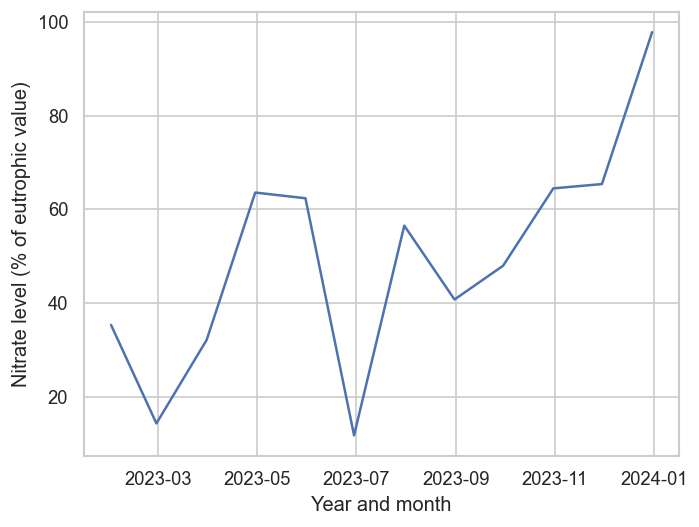

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

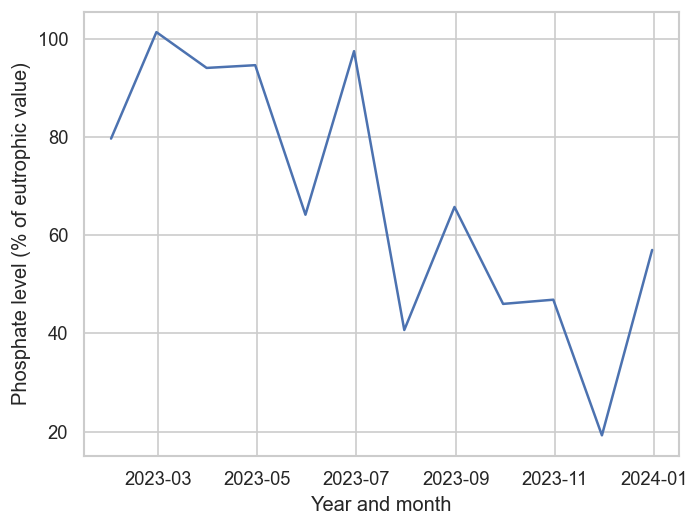

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='ME')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")


<Axes: >

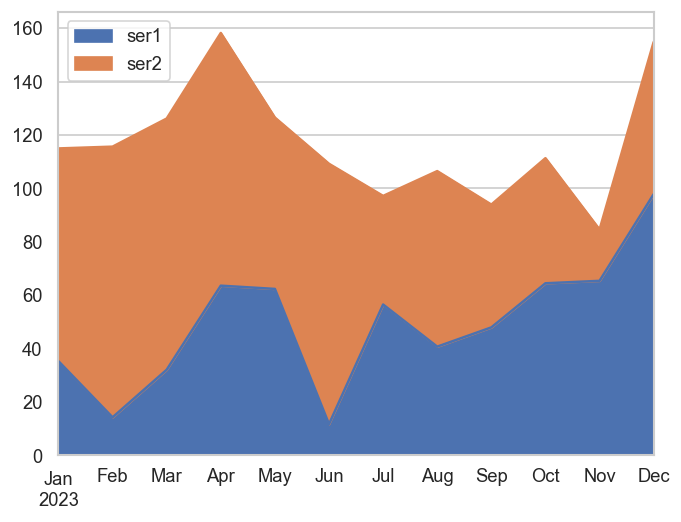

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()


# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

## Problem 3: Bivariate Analysis on My Datasets

For this section, I analyzed all three imported datasets available in the project: `Loan_Default.csv`, `bank_customers.csv`, and the accepted Lending Club loan data. I focused on plots that answer a real question for each dataset instead of plotting relationships that are only mathematically obvious. Each dataset section includes relationship plots, outlier or data-quality checks, and a conclusion tied back to the rubric.


## Dataset 1: Loan Default Data

Business question: which applicant or loan characteristics are most related to whether a borrower defaulted? In this file, `Status = 1` means the borrower defaulted and `Status = 0` means the borrower did not default.


In [5]:
loan_default = pd.read_csv("Loan_Default.csv")

print(f"Loan default dataset shape: {loan_default.shape[0]:,} rows and {loan_default.shape[1]:,} columns")
print(f"Default rate: {loan_default['Status'].mean():.1%}")
display(loan_default.head())
display(loan_default.isna().sum().sort_values(ascending=False).head(10).to_frame("missing_values"))


Loan default dataset shape: 148,670 rows and 34 columns
Default rate: 24.6%


,ID,year,loan_limit,Gender,approv_in_adv,loan_type,loan_purpose,Credit_Worthiness,open_credit,business_or_commercial,loan_amount,rate_of_interest,Interest_rate_spread,Upfront_charges,term,Neg_ammortization,interest_only,lump_sum_payment,property_value,construction_type,occupancy_type,Secured_by,total_units,income,credit_type,Credit_Score,co-applicant_credit_type,age,submission_of_application,LTV,Region,Security_Type,Status,dtir1
0,24890,2019,cf,Sex Not Available,nopre,type1,p1,l1,nopc,nob/c,116500,NaN,NaN,NaN,360.0,not_neg,not_int,not_lpsm,118000.0,sb,pr,home,1U,1740.0,EXP,758,CIB,25-34,to_inst,98.728814,south,direct,1,45.0
1,24891,2019,cf,Male,nopre,type2,p1,l1,nopc,b/c,206500,NaN,NaN,NaN,360.0,not_neg,not_int,lpsm,NaN,sb,pr,home,1U,4980.0,EQUI,552,EXP,55-64,to_inst,NaN,North,direct,1,NaN
2,24892,2019,cf,Male,pre,type1,p1,l1,nopc,nob/c,406500,4.56,0.2000,595.0,360.0,neg_amm,not_int,not_lpsm,508000.0,sb,pr,home,1U,9480.0,EXP,834,CIB,35-44,to_inst,80.019685,south,direct,0,46.0
3,24893,2019,cf,Male,nopre,type1,p4,l1,nopc,nob/c,456500,4.25,0.6810,NaN,360.0,not_neg,not_int,not_lpsm,658000.0,sb,pr,home,1U,11880.0,EXP,587,CIB,45-54,not_inst,69.376900,North,direct,0,42.0
4,24894,2019,cf,Joint,pre,type1,p1,l1,nopc,nob/c,696500,4.00,0.3042,0.0,360.0,not_neg,not_int,not_lpsm,758000.0,sb,pr,home,1U,10440.0,CRIF,602,EXP,25-34,not_inst,91.886544,North,direct,0,39.0


,missing_values
Upfront_charges,39642
Interest_rate_spread,36639
rate_of_interest,36439
dtir1,24121
LTV,15098
property_value,15098
income,9150
loan_limit,3344
approv_in_adv,908
submission_of_application,200


,numeric_variable,correlation_with_default
0,dtir1,0.078083
1,income,-0.065119
2,property_value,-0.048864
3,LTV,0.038895
4,loan_amount,-0.036825
5,rate_of_interest,0.022957
6,Upfront_charges,-0.019138
7,Credit_Score,0.004004
8,term,-0.000240


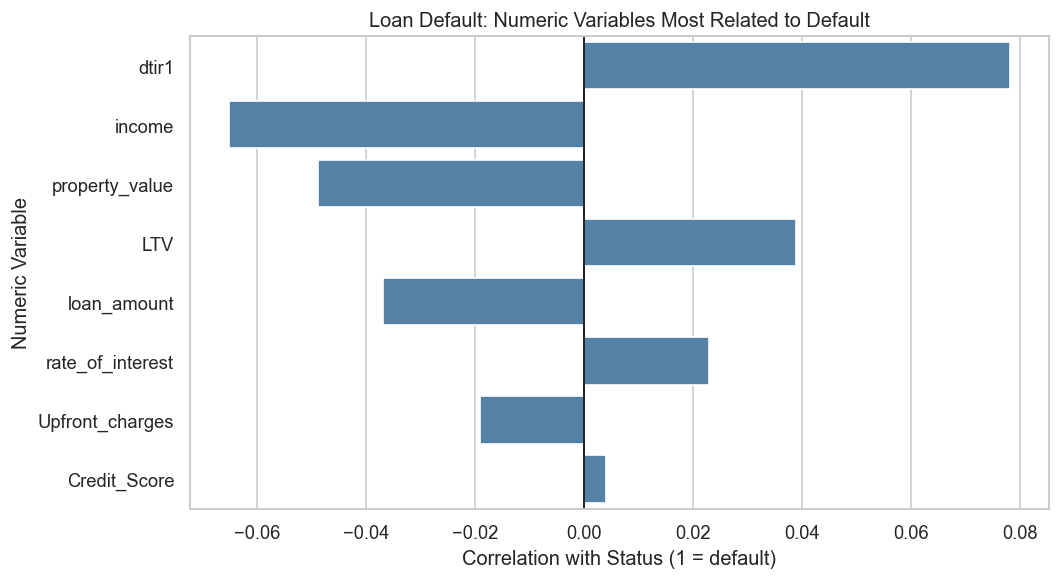

In [6]:
loan_numeric = loan_default.select_dtypes(include=np.number).drop(columns=["ID", "year"], errors="ignore")
loan_corr = loan_numeric.corr()

status_corr_df = (
    loan_corr["Status"]
    .drop("Status")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .reset_index()
)
status_corr_df.columns = ["numeric_variable", "correlation_with_default"]
display(status_corr_df)

plt.figure(figsize=(9, 5))
sns.barplot(
    data=status_corr_df.head(8),
    x="correlation_with_default",
    y="numeric_variable",
    color="steelblue"
)
plt.axvline(0, color="black", linewidth=1)
plt.title("Loan Default: Numeric Variables Most Related to Default")
plt.xlabel("Correlation with Status (1 = default)")
plt.ylabel("Numeric Variable")
plt.tight_layout()
plt.show()


,Income quintile,min_value,max_value,variable,Debt-to-income quintile,Loan-to-value quintile
0,Q1 lowest,0.000000,3420.000000,income,NaN,NaN
1,Q2,3480.000000,4980.000000,income,NaN,NaN
2,Q3,5040.000000,6720.000000,income,NaN,NaN
3,Q4,6780.000000,9420.000000,income,NaN,NaN
4,Q5 highest,9480.000000,578580.000000,income,NaN,NaN
5,NaN,5.000000,30.000000,dtir1,Q1 lowest,NaN
6,NaN,31.000000,37.000000,dtir1,Q2,NaN
7,NaN,38.000000,42.000000,dtir1,Q3,NaN
8,NaN,43.000000,46.000000,dtir1,Q4,NaN
9,NaN,47.000000,61.000000,dtir1,Q5 highest,NaN


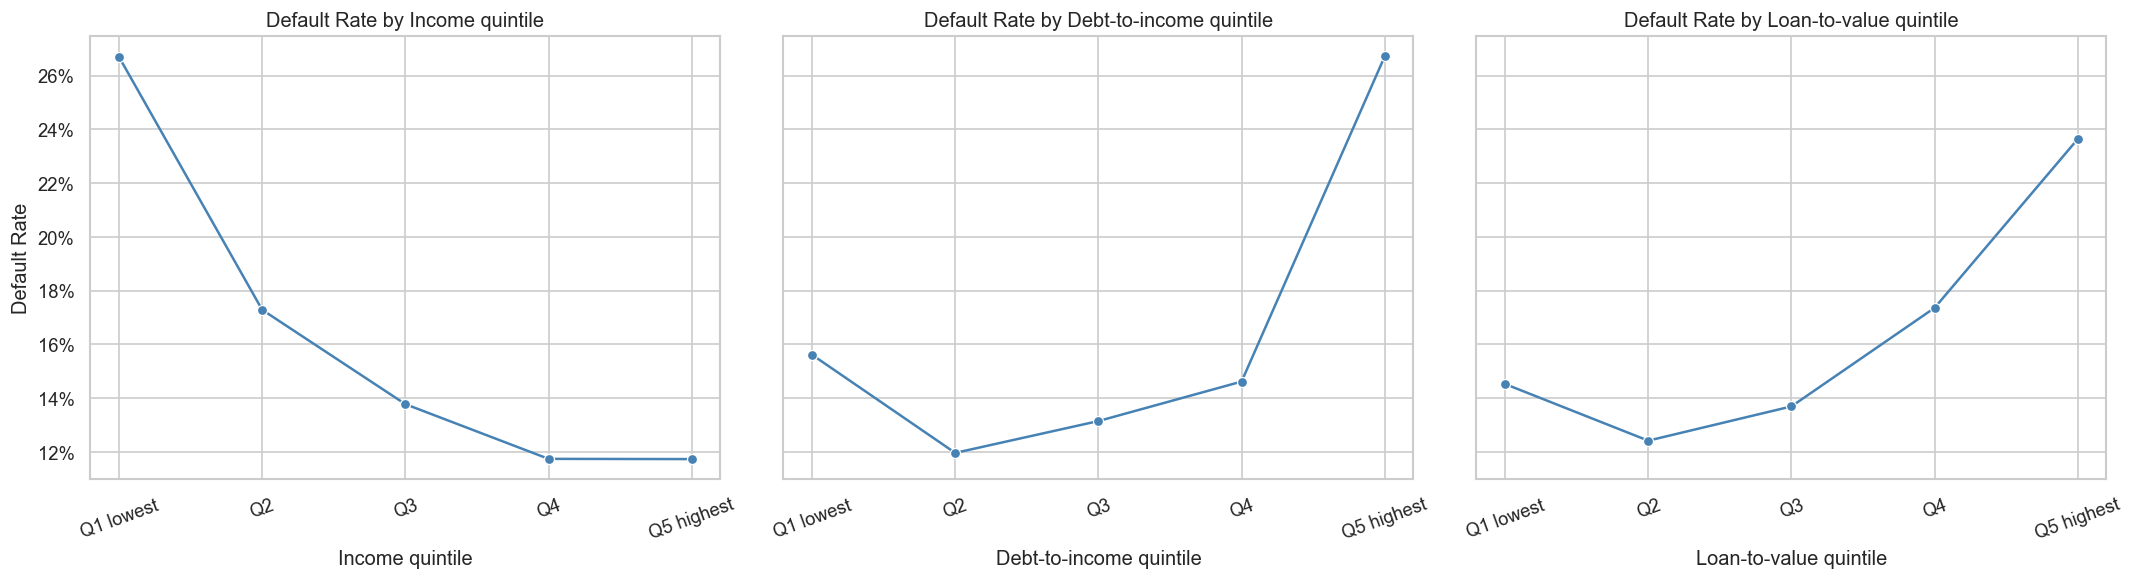

In [7]:
loan_risk = loan_default[["Status", "income", "dtir1", "LTV", "loan_amount"]].dropna().copy()
quintile_labels = ["Q1 lowest", "Q2", "Q3", "Q4", "Q5 highest"]

loan_risk["Income quintile"] = pd.qcut(loan_risk["income"], q=5, labels=quintile_labels, duplicates="drop")
loan_risk["Debt-to-income quintile"] = pd.qcut(loan_risk["dtir1"], q=5, labels=quintile_labels, duplicates="drop")
loan_risk["Loan-to-value quintile"] = pd.qcut(loan_risk["LTV"], q=5, labels=quintile_labels, duplicates="drop")

range_tables = []
for raw_column, quintile_column in [
    ("income", "Income quintile"),
    ("dtir1", "Debt-to-income quintile"),
    ("LTV", "Loan-to-value quintile")
]:
    ranges = (
        loan_risk
        .groupby(quintile_column, observed=True)[raw_column]
        .agg(min_value="min", max_value="max")
        .reset_index()
    )
    ranges["variable"] = raw_column
    range_tables.append(ranges)

display(pd.concat(range_tables, ignore_index=True))

risk_plots = []
for column in ["Income quintile", "Debt-to-income quintile", "Loan-to-value quintile"]:
    grouped = (
        loan_risk
        .groupby(column, observed=True)["Status"]
        .agg(default_rate="mean", loan_count="size")
        .reset_index()
    )
    risk_plots.append((column, grouped))

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)
for ax, (column, grouped) in zip(axes, risk_plots):
    sns.lineplot(data=grouped, x=column, y="default_rate", marker="o", ax=ax, color="steelblue")
    ax.set_title(f"Default Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=20)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

plt.tight_layout()
plt.show()


,category,default_rate,loan_count,variable
7,EQUI,0.999935,15298,credit_type
1,type2,0.345439,20762,loan_type
4,l2,0.317736,6326,Credit_Worthiness
17,North-East,0.304453,1235,Region
15,>74,0.300070,7175,age
14,<25,0.289454,1337,age
18,central,0.275382,8697,Region
13,65-74,0.268560,20744,age
19,south,0.266293,64016,Region
12,55-64,0.258868,32534,age


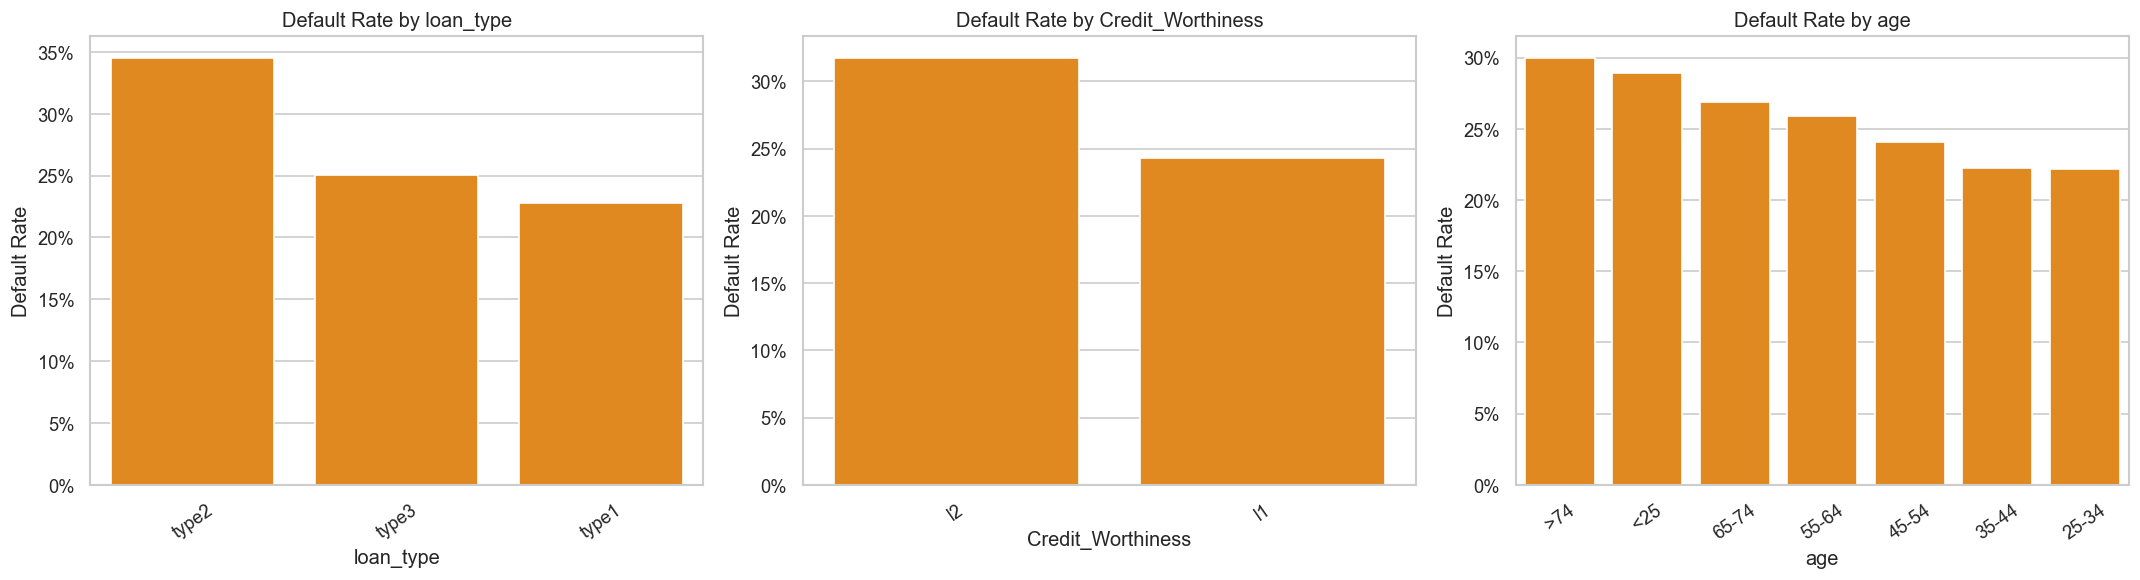

In [8]:
loan_category_rates = []
for column in ["loan_type", "Credit_Worthiness", "credit_type", "age", "Region"]:
    grouped = (
        loan_default
        .dropna(subset=[column, "Status"])
        .groupby(column)["Status"]
        .agg(default_rate="mean", loan_count="size")
        .reset_index()
        .rename(columns={column: "category"})
    )
    grouped["variable"] = column
    loan_category_rates.append(grouped)

loan_category_rates = pd.concat(loan_category_rates, ignore_index=True)
display(loan_category_rates.sort_values("default_rate", ascending=False).head(15))

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
for ax, column in zip(axes, ["loan_type", "Credit_Worthiness", "age"]):
    plot_data = loan_category_rates[loan_category_rates["variable"] == column].sort_values("default_rate", ascending=False)
    sns.barplot(data=plot_data, x="category", y="default_rate", ax=ax, color="darkorange")
    ax.set_title(f"Default Rate by {column}")
    ax.set_xlabel(column)
    ax.set_ylabel("Default Rate")
    ax.tick_params(axis="x", rotation=35)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

plt.tight_layout()
plt.show()


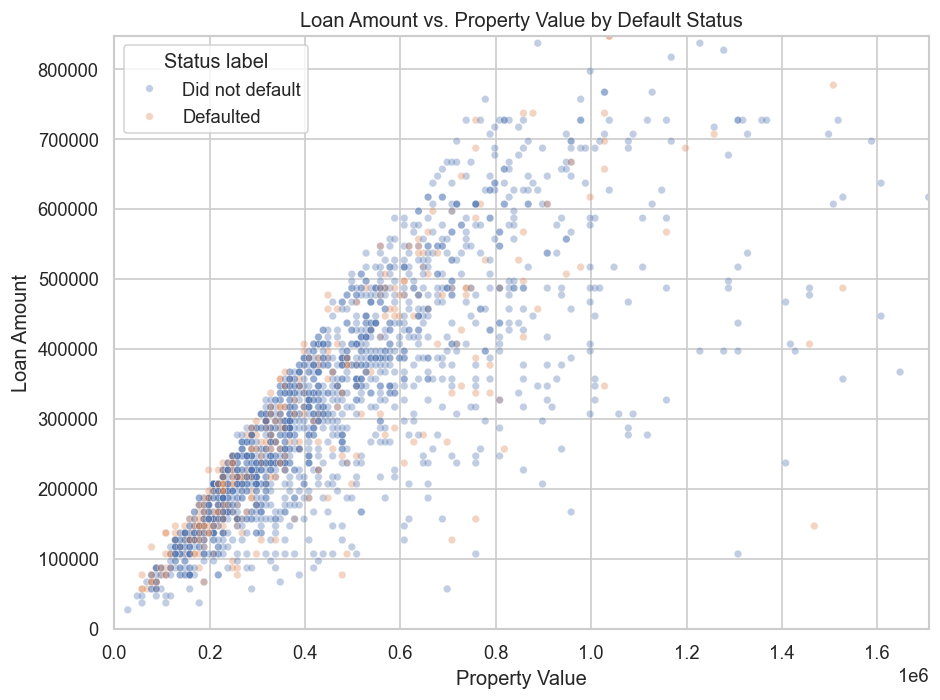

In [9]:
loan_relationship_sample = loan_default.dropna(subset=["property_value", "loan_amount", "Status"]).sample(
    n=min(2000, loan_default.dropna(subset=["property_value", "loan_amount", "Status"]).shape[0]),
    random_state=0
).copy()
loan_relationship_sample["Status label"] = loan_relationship_sample["Status"].map({0: "Did not default", 1: "Defaulted"})

plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=loan_relationship_sample,
    x="property_value",
    y="loan_amount",
    hue="Status label",
    alpha=0.35,
    s=20
)
plt.xlim(0, loan_relationship_sample["property_value"].quantile(0.99))
plt.ylim(0, loan_relationship_sample["loan_amount"].quantile(0.99))
plt.title("Loan Amount vs. Property Value by Default Status")
plt.xlabel("Property Value")
plt.ylabel("Loan Amount")
plt.tight_layout()
plt.show()


,column,median,min,max,iqr_outliers,upper_outlier_cutoff
0,loan_amount,296500.00000,16500.000000,3576500.00,1895,7.965000e+05
1,property_value,418000.00000,8000.000000,16508000.00,5266,1.168000e+06
2,income,5760.00000,0.000000,578580.00,6546,1.572000e+04
3,LTV,75.13587,0.967478,7831.25,1882,1.247482e+02
4,Upfront_charges,2596.45000,0.000000,60000.00,2880,1.115901e+04
5,dtir1,39.00000,5.000000,61.00,2013,6.600000e+01


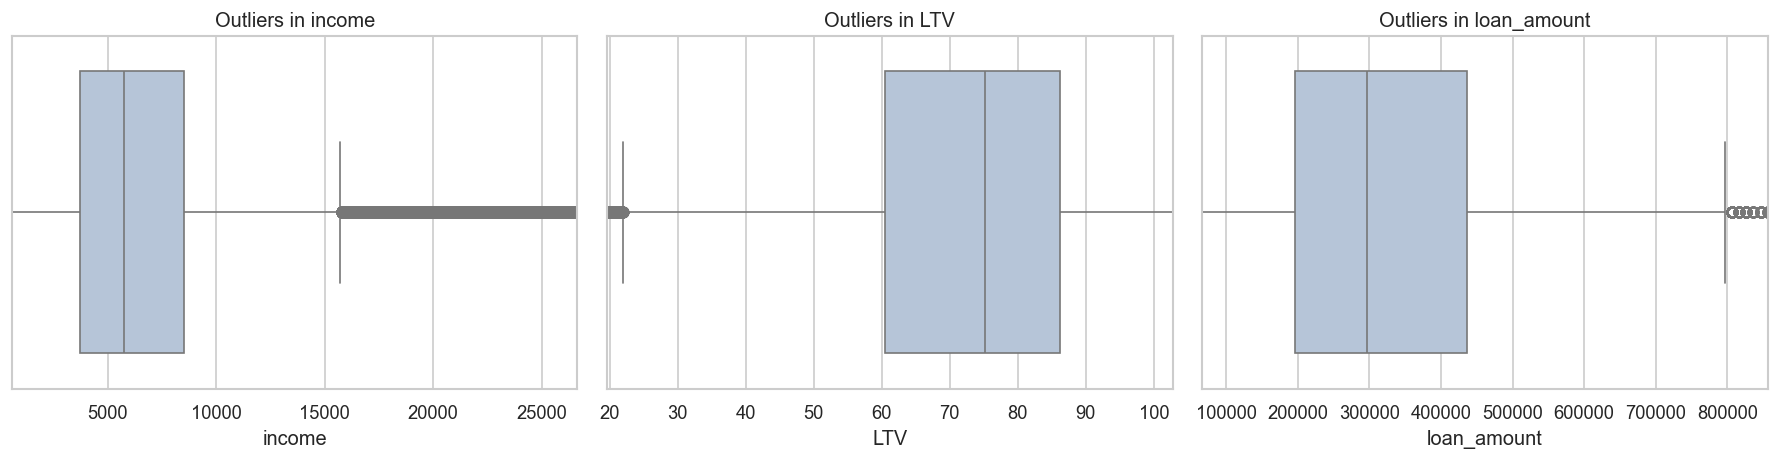

Unique values in year column: [2019]


In [10]:
loan_outlier_columns = ["loan_amount", "property_value", "income", "LTV", "Upfront_charges", "dtir1"]
loan_outlier_summary = []
for column in loan_outlier_columns:
    values = loan_default[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    loan_outlier_summary.append({
        "column": column,
        "median": values.median(),
        "min": values.min(),
        "max": values.max(),
        "iqr_outliers": ((values < lower_bound) | (values > upper_bound)).sum(),
        "upper_outlier_cutoff": upper_bound
    })

display(pd.DataFrame(loan_outlier_summary))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["income", "LTV", "loan_amount"]):
    sns.boxplot(data=loan_default, x=column, ax=ax, color="lightsteelblue")
    ax.set_title(f"Outliers in {column}")
    ax.set_xlim(loan_default[column].quantile(0.01), loan_default[column].quantile(0.99))
plt.tight_layout()
plt.show()

print("Unique values in year column:", loan_default["year"].dropna().unique())


### Loan Default Dataset Conclusions

The loan default data is usable for bivariate analysis because it contains many loan, borrower, and credit variables connected to the target `Status`. The most important finding is that no single numeric variable has a strong linear relationship with default. The strongest numeric relationships are `dtir1`, `income`, `property_value`, `LTV`, and `loan_amount`, but each correlation is weak on its own.

The default-rate plots are more meaningful than a raw correlation table. Lower-income applicants and applicants in the highest debt-to-income and loan-to-value groups show higher default rates, which fits the business expectation that affordability matters. Categorical variables such as `loan_type`, `Credit_Worthiness`, and age group also show visible differences in default rates.

The scatterplot of `loan_amount` and `property_value` is useful for checking redundancy and loan structure: larger properties usually have larger loans. This relationship is expected, so it is not enough by itself to explain default. The outlier table and boxplots show extreme values in `income`, `LTV`, `property_value`, and `loan_amount`; these should be reviewed before modeling. The `year` column only contains 2019, so this dataset does not support a meaningful time trend.


## Dataset 2: Bank Customers Data

Business question: can customer banking profile variables help estimate loan-default risk? This dataset does not contain actual loan-default outcomes, so the plots below use only plausible risk proxy variables that exist in the file: customer age, account tenure, and account type. These plots should be read as risk-screening context, not as proof of default prediction.


In [11]:
bank_customers = pd.read_csv("bank_customers.csv")

print(f"Bank customers dataset shape: {bank_customers.shape[0]:,} rows and {bank_customers.shape[1]:,} columns")
display(bank_customers.head())
display(bank_customers.isna().sum().to_frame("missing_values"))

def parse_dates_safely(series):
    try:
        return pd.to_datetime(series, errors="coerce", format="mixed")
    except TypeError:
        return pd.to_datetime(series, errors="coerce")

bank_customers["BirthDate_parsed"] = parse_dates_safely(bank_customers["BirthDate"])
bank_customers["AccountOpened_parsed"] = parse_dates_safely(bank_customers["AccountOpened"])
bank_customers["Future_AccountOpened"] = bank_customers["AccountOpened_parsed"] > pd.Timestamp.today()
bank_customers["Opened_Before_Birth"] = bank_customers["AccountOpened_parsed"] < bank_customers["BirthDate_parsed"]
bank_customers["Current_Age"] = (pd.Timestamp.today() - bank_customers["BirthDate_parsed"]).dt.days / 365.25
bank_customers["Account_Tenure_Years"] = (pd.Timestamp.today() - bank_customers["AccountOpened_parsed"]).dt.days / 365.25
bank_customers["Age_At_Account_Opening"] = (
    bank_customers["AccountOpened_parsed"] - bank_customers["BirthDate_parsed"]
).dt.days / 365.25

bank_customers["Usable_Record"] = (
    bank_customers["AccountType"].notna()
    & bank_customers["BirthDate_parsed"].notna()
    & bank_customers["AccountOpened_parsed"].notna()
    & ~bank_customers["Future_AccountOpened"]
    & ~bank_customers["Opened_Before_Birth"]
)

usable_bank_records = bank_customers[bank_customers["Usable_Record"]].copy()

# These are not true default labels. They are simple risk proxies based on common underwriting intuition:
# younger customers and customers with short account histories may have less demonstrated financial history.
usable_bank_records["Short_Tenure_Flag"] = usable_bank_records["Account_Tenure_Years"] < 5
usable_bank_records["Young_Customer_Flag"] = usable_bank_records["Current_Age"] < 30
usable_bank_records["Higher_Risk_Profile"] = (
    usable_bank_records["Short_Tenure_Flag"] | usable_bank_records["Young_Customer_Flag"]
)
usable_bank_records["Risk_Profile"] = np.where(
    usable_bank_records["Higher_Risk_Profile"],
    "Higher proxy risk",
    "Lower proxy risk"
)

redundant_or_unusable_fields = pd.DataFrame({
    "field": ["CustomerID", "AccountID", "SSN", "BirthDate", "AccountOpened", "AccountType"],
    "use_for_default_risk": ["No", "No", "No", "Derived only", "Derived only", "Possible weak proxy"],
    "reason": [
        "Identifier only; not a business risk variable",
        "Identifier only; not a business risk variable",
        "Sensitive personal information; should be removed or protected",
        "Useful only after deriving customer age",
        "Useful only after deriving account tenure and removing future dates",
        "May describe banking relationship, but not enough to predict default by itself"
    ]
})

risk_proxy_summary = (
    usable_bank_records
    .groupby("AccountType")
    .agg(
        usable_records=("CustomerID", "size"),
        median_age=("Current_Age", "median"),
        median_account_tenure=("Account_Tenure_Years", "median"),
        higher_proxy_risk_rate=("Higher_Risk_Profile", "mean")
    )
    .reset_index()
)

print(f"Usable historical records for risk-proxy plots: {len(usable_bank_records)} of {len(bank_customers)}")
display(redundant_or_unusable_fields)
display(risk_proxy_summary)


Bank customers dataset shape: 100 rows and 6 columns


,CustomerID,BirthDate,SSN,AccountID,AccountOpened,AccountType
0,0.0,1980,530-47-1866,4.0,1959-12-06,checking
1,1.0,no date,682-76-9175,67.0,2039-02-20,cd
2,2.0,1976-12-15,377-98-9839,NaN,2019-03-25,checking
3,3.0,2003-10-18,474-05-7613,86.0,2004-03-02,cd
4,4.0,1985-12-06,750-55-5509,77.0,2059-05-05,cd


,missing_values
CustomerID,1
BirthDate,1
SSN,1
AccountID,2
AccountOpened,1
AccountType,1


Usable historical records for risk-proxy plots: 39 of 100


,field,use_for_default_risk,reason
0,CustomerID,No,Identifier only; not a business risk variable
1,AccountID,No,Identifier only; not a business risk variable
2,SSN,No,Sensitive personal information; should be remo...
3,BirthDate,Derived only,Useful only after deriving customer age
4,AccountOpened,Derived only,Useful only after deriving account tenure and ...
5,AccountType,Possible weak proxy,"May describe banking relationship, but not eno..."


,AccountType,usable_records,median_age,median_account_tenure,higher_proxy_risk_rate
0,cd,8,65.048597,34.732375,0.250000
1,checking,16,46.375086,17.449692,0.250000
2,savings,15,46.012320,16.799452,0.333333


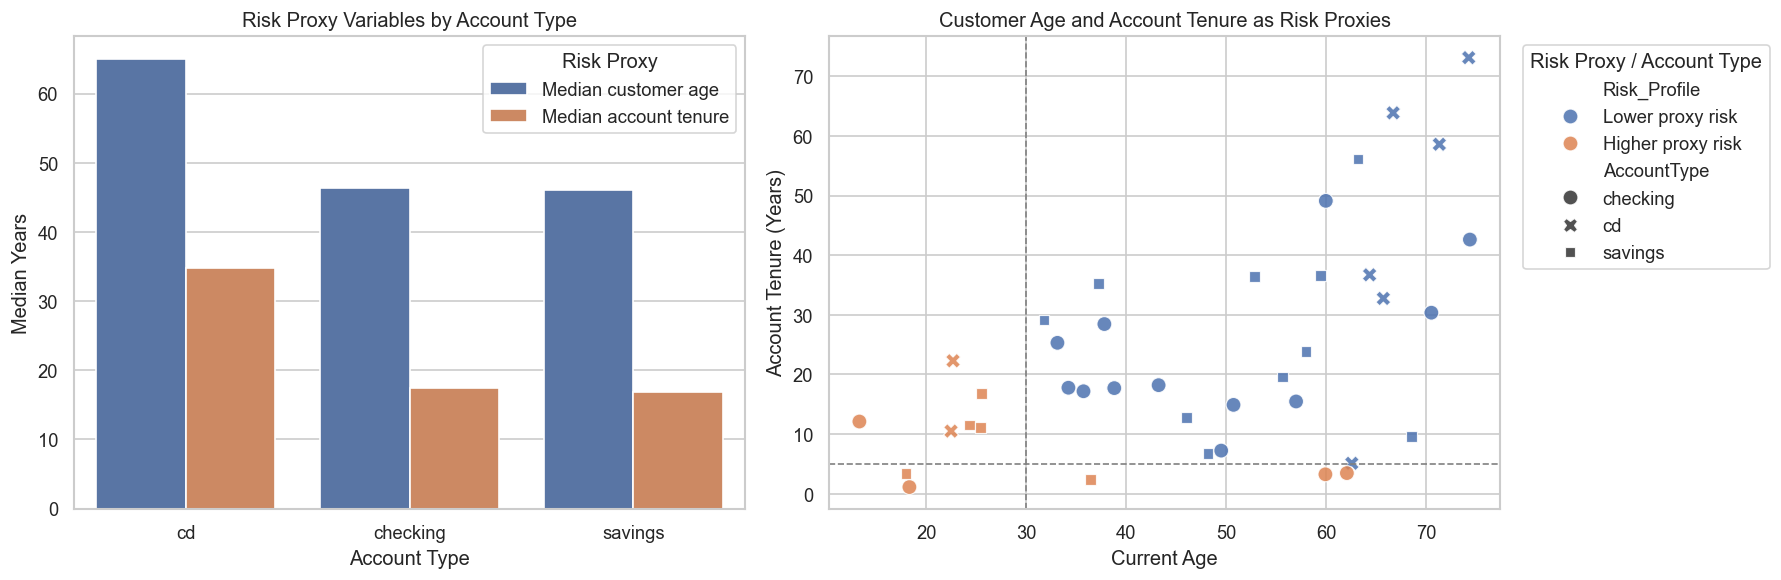

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

risk_proxy_long = risk_proxy_summary.melt(
    id_vars="AccountType",
    value_vars=["median_age", "median_account_tenure"],
    var_name="risk_proxy_variable",
    value_name="median_years"
)
risk_proxy_long["risk_proxy_variable"] = risk_proxy_long["risk_proxy_variable"].replace({
    "median_age": "Median customer age",
    "median_account_tenure": "Median account tenure"
})

sns.barplot(
    data=risk_proxy_long,
    x="AccountType",
    y="median_years",
    hue="risk_proxy_variable",
    ax=axes[0]
)
axes[0].set_title("Risk Proxy Variables by Account Type")
axes[0].set_xlabel("Account Type")
axes[0].set_ylabel("Median Years")
axes[0].legend(title="Risk Proxy")

sns.scatterplot(
    data=usable_bank_records,
    x="Current_Age",
    y="Account_Tenure_Years",
    hue="Risk_Profile",
    style="AccountType",
    s=80,
    alpha=0.85,
    ax=axes[1]
)
axes[1].axvline(30, color="gray", linestyle="--", linewidth=1)
axes[1].axhline(5, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Customer Age and Account Tenure as Risk Proxies")
axes[1].set_xlabel("Current Age")
axes[1].set_ylabel("Account Tenure (Years)")
axes[1].legend(title="Risk Proxy / Account Type", bbox_to_anchor=(1.02, 1), loc="upper left")

plt.tight_layout()
plt.show()


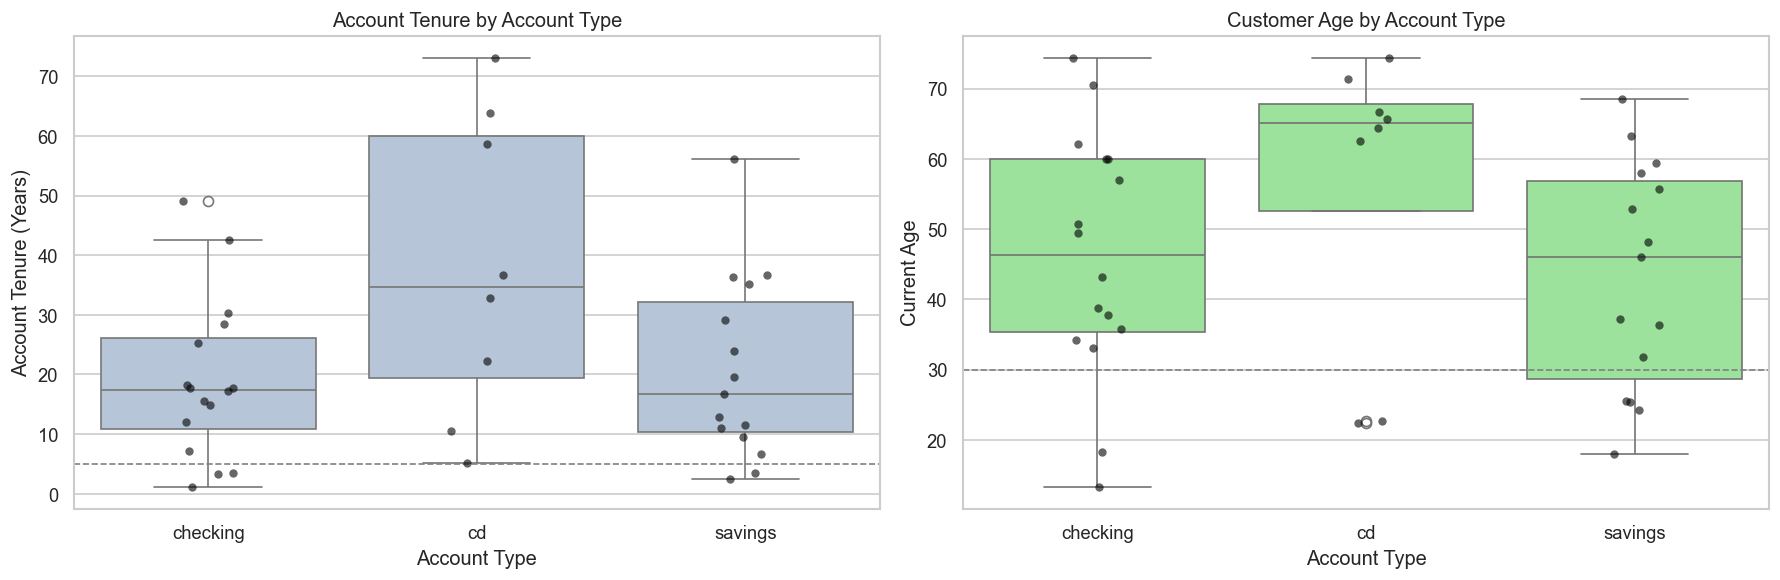

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.boxplot(
    data=usable_bank_records,
    x="AccountType",
    y="Account_Tenure_Years",
    color="lightsteelblue",
    ax=axes[0]
)
sns.stripplot(
    data=usable_bank_records,
    x="AccountType",
    y="Account_Tenure_Years",
    color="black",
    alpha=0.6,
    jitter=True,
    ax=axes[0]
)
axes[0].axhline(5, color="gray", linestyle="--", linewidth=1)
axes[0].set_title("Account Tenure by Account Type")
axes[0].set_xlabel("Account Type")
axes[0].set_ylabel("Account Tenure (Years)")

sns.boxplot(
    data=usable_bank_records,
    x="AccountType",
    y="Current_Age",
    color="lightgreen",
    ax=axes[1]
)
sns.stripplot(
    data=usable_bank_records,
    x="AccountType",
    y="Current_Age",
    color="black",
    alpha=0.6,
    jitter=True,
    ax=axes[1]
)
axes[1].axhline(30, color="gray", linestyle="--", linewidth=1)
axes[1].set_title("Customer Age by Account Type")
axes[1].set_xlabel("Account Type")
axes[1].set_ylabel("Current Age")

plt.tight_layout()
plt.show()


### Bank Customers Dataset Conclusions

For loan-default prediction, this dataset has only weak proxy variables. It does not contain the actual default target, loan amount, income, credit score, debt-to-income ratio, payment history, or delinquency history. Because of that, it should not be used as the main dataset for a default model.

The plots focus only on variables that could plausibly relate to risk: customer age, account tenure, and account type. The first plot compares median customer age and median account tenure by account type. The scatterplot shows how age and tenure separate lower and higher proxy-risk records, where the proxy flags customers who are younger than 30 or have less than five years of usable account history. This is not a true default label, but it is a reasonable screening proxy when the real default outcome is missing.

The tenure and age boxplots are also interpretable because they show whether different account types have different customer profiles. If this file could be joined to a real loan-performance dataset, `Current_Age`, `Account_Tenure_Years`, and `AccountType` could be tested as possible predictors.

Rubric points: there are no meaningful numeric correlations to report because `CustomerID` and `AccountID` are identifiers. Redundant or unusable variables are handled in the analysis table instead of plotted: IDs are not predictive, `SSN` is sensitive and should be removed, and date fields should only be used after deriving age/tenure. Outliers/data-quality issues are future account-opened dates and accounts opened before birth; those records were excluded from the plots. A time-series line plot is not appropriate for this dataset because many account-opened dates are invalid or future-dated.


## Dataset 3: Accepted Lending Club Loan Data

Business question: which borrower and loan characteristics are associated with worse loan outcomes, and how do accepted loans change over time?


In [14]:
accepted_path = Path("DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
accepted_columns = [
    "loan_amnt", "funded_amnt", "int_rate", "installment", "annual_inc", "dti",
    "fico_range_low", "fico_range_high", "open_acc", "revol_bal", "revol_util",
    "total_acc", "loan_status", "grade", "purpose", "issue_d"
]

accepted_total_rows = sum(1 for _ in open(accepted_path, encoding="utf-8")) - 1
accepted_sample_target = 50000
accepted_sample_every = max(accepted_total_rows // accepted_sample_target, 1)

accepted_loans = pd.read_csv(
    accepted_path,
    usecols=accepted_columns,
    skiprows=lambda row_number: row_number > 0 and row_number % accepted_sample_every != 0,
    low_memory=False
)

accepted_loans["issue_date"] = pd.to_datetime(accepted_loans["issue_d"], format="%b-%Y", errors="coerce")
accepted_loans["issue_year"] = accepted_loans["issue_date"].dt.year
accepted_loans["fico_average"] = (accepted_loans["fico_range_low"] + accepted_loans["fico_range_high"]) / 2
accepted_loans["bad_loan"] = accepted_loans["loan_status"].isin([
    "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
    "Does not meet the credit policy. Status:Charged Off"
]).astype(int)

print(f"Accepted Lending Club sample shape: {accepted_loans.shape[0]:,} rows and {accepted_loans.shape[1]:,} columns")
print(f"Full accepted-loans file has approximately {accepted_total_rows:,} rows")
print(f"Bad-loan rate in sample: {accepted_loans['bad_loan'].mean():.1%}")
display(accepted_loans.head())
display(accepted_loans["loan_status"].value_counts().head(10).to_frame("records"))
display(accepted_loans.isna().sum().sort_values(ascending=False).head(10).to_frame("missing_values"))


Accepted Lending Club sample shape: 50,237 rows and 20 columns
Full accepted-loans file has approximately 2,260,701 rows
Bad-loan rate in sample: 13.0%


,loan_amnt,funded_amnt,int_rate,installment,grade,annual_inc,issue_d,loan_status,purpose,dti,fico_range_low,fico_range_high,open_acc,revol_bal,revol_util,total_acc,issue_date,issue_year,fico_average,bad_loan
0,8650.0,8650.0,5.32,260.50,A,100000.00,Dec-2015,Fully Paid,credit_card,7.28,750.0,754.0,15.0,7158.0,26.7,24.0,2015-12-01,2015,752.0,0
1,5000.0,5000.0,7.91,156.48,A,32000.00,Dec-2015,Fully Paid,credit_card,13.73,685.0,689.0,7.0,5552.0,41.1,10.0,2015-12-01,2015,687.0,0
2,3200.0,3200.0,8.49,101.01,B,30407.00,Dec-2015,Fully Paid,medical,20.61,710.0,714.0,5.0,1061.0,30.3,13.0,2015-12-01,2015,712.0,0
3,24000.0,24000.0,12.88,544.61,C,75181.21,Dec-2015,Current,debt_consolidation,31.57,720.0,724.0,13.0,17497.0,44.4,37.0,2015-12-01,2015,722.0,0
4,20000.0,20000.0,9.17,637.58,B,130000.00,Dec-2015,Fully Paid,debt_consolidation,12.77,715.0,719.0,8.0,12187.0,36.5,13.0,2015-12-01,2015,717.0,0


,records
loan_status,
Fully Paid,23929
Current,19538
Charged Off,5937
Late (31-120 days),482
In Grace Period,187
Late (16-30 days),102
Does not meet the credit policy. Status:Fully Paid,41
Does not meet the credit policy. Status:Charged Off,20
Default,1


,missing_values
revol_util,44
dti,44
loan_amnt,0
fico_range_high,0
fico_average,0
issue_year,0
issue_date,0
total_acc,0
revol_bal,0
open_acc,0


,numeric_variable,correlation_with_bad_loan
0,int_rate,0.206374
1,fico_range_low,-0.123949
2,fico_average,-0.123948
3,fico_range_high,-0.123948
4,revol_util,0.064993
5,dti,0.038327
6,annual_inc,-0.037017
7,revol_bal,-0.030172
8,installment,0.023661
9,loan_amnt,0.016829


,variable_1,variable_2,correlation,absolute_correlation
110,fico_range_high,fico_average,1.000000,1.000000
96,fico_range_low,fico_average,1.000000,1.000000
91,fico_range_low,fico_range_high,1.000000,1.000000
1,loan_amnt,funded_amnt,0.999777,0.999777
17,funded_amnt,installment,0.945761,0.945761
3,loan_amnt,installment,0.945427,0.945427
123,open_acc,total_acc,0.714526,0.714526
94,fico_range_low,revol_util,-0.477811,0.477811


,fico_band,bad_loan_rate,average_interest_rate,loan_count
0,600-659,0.538462,14.910000,13
1,660-699,0.161899,14.596143,28876
2,700-739,0.100511,11.910249,15073
3,740-779,0.063137,9.433708,4609
4,780+,0.032413,8.130324,1666


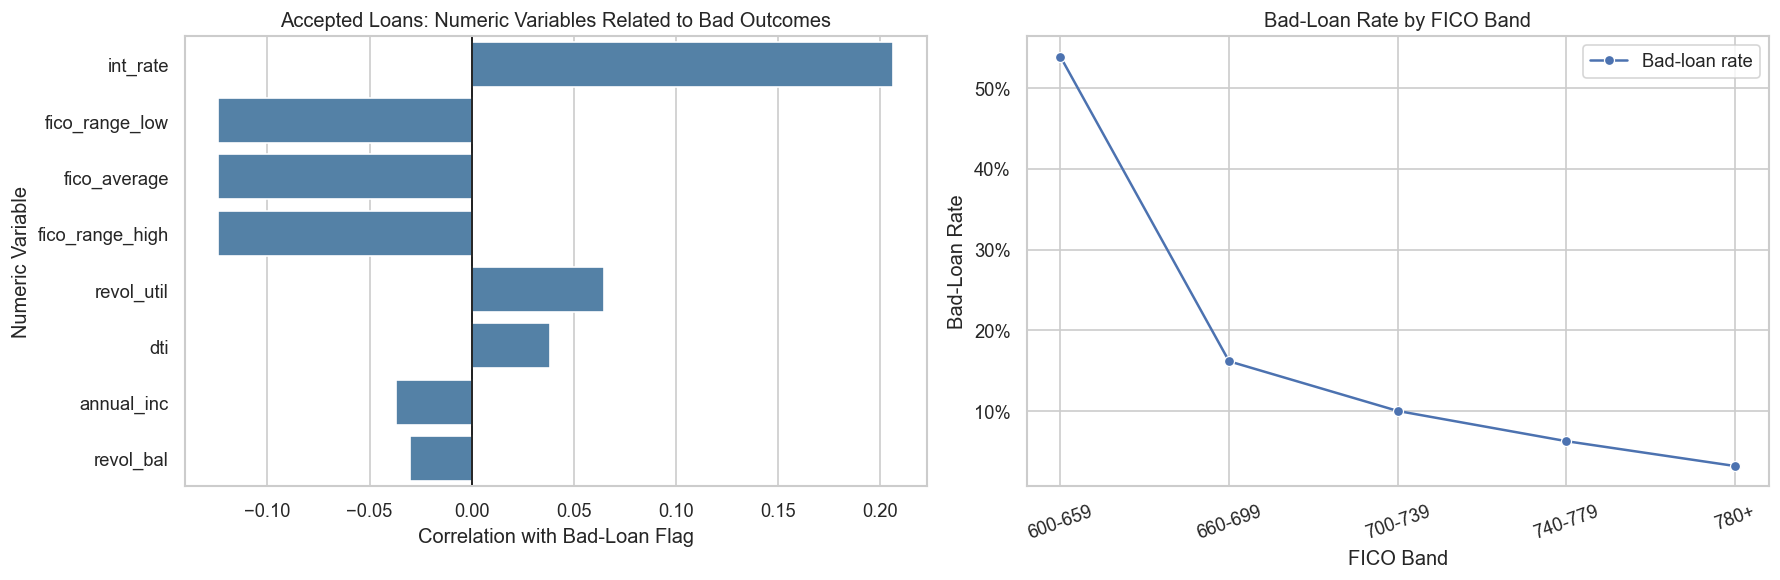

In [15]:
accepted_numeric = accepted_loans.select_dtypes(include=np.number).drop(columns=["issue_year"], errors="ignore")
accepted_corr = accepted_numeric.corr()

bad_loan_corr_df = (
    accepted_corr["bad_loan"]
    .drop("bad_loan")
    .dropna()
    .sort_values(key=lambda values: values.abs(), ascending=False)
    .reset_index()
)
bad_loan_corr_df.columns = ["numeric_variable", "correlation_with_bad_loan"]
display(bad_loan_corr_df)

redundant_pairs = accepted_corr.where(np.triu(np.ones(accepted_corr.shape), k=1).astype(bool)).stack().reset_index()
redundant_pairs.columns = ["variable_1", "variable_2", "correlation"]
redundant_pairs["absolute_correlation"] = redundant_pairs["correlation"].abs()
redundant_pairs = redundant_pairs.sort_values("absolute_correlation", ascending=False).head(8)
display(redundant_pairs)

accepted_loans["fico_band"] = pd.cut(
    accepted_loans["fico_average"],
    bins=[600, 660, 700, 740, 780, 850],
    labels=["600-659", "660-699", "700-739", "740-779", "780+"]
)
fico_risk = (
    accepted_loans
    .dropna(subset=["fico_band", "bad_loan", "int_rate"])
    .groupby("fico_band", observed=True)
    .agg(
        bad_loan_rate=("bad_loan", "mean"),
        average_interest_rate=("int_rate", "mean"),
        loan_count=("bad_loan", "size")
    )
    .reset_index()
)
display(fico_risk)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(
    data=bad_loan_corr_df.head(8),
    x="correlation_with_bad_loan",
    y="numeric_variable",
    color="steelblue",
    ax=axes[0]
)
axes[0].axvline(0, color="black", linewidth=1)
axes[0].set_title("Accepted Loans: Numeric Variables Related to Bad Outcomes")
axes[0].set_xlabel("Correlation with Bad-Loan Flag")
axes[0].set_ylabel("Numeric Variable")

sns.lineplot(data=fico_risk, x="fico_band", y="bad_loan_rate", marker="o", ax=axes[1], label="Bad-loan rate")
axes[1].set_title("Bad-Loan Rate by FICO Band")
axes[1].set_xlabel("FICO Band")
axes[1].set_ylabel("Bad-Loan Rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
axes[1].tick_params(axis="x", rotation=20)

plt.tight_layout()
plt.show()


,grade,bad_loan_rate,loan_count
0,A,0.037002,9648
1,B,0.088881,14795
2,C,0.146493,14301
3,D,0.201279,7194
4,E,0.283099,3059
5,F,0.361083,997
6,G,0.415638,243


,purpose,bad_loan_rate,loan_count
9,small_business,0.171540,513
7,moving,0.155425,341
2,debt_consolidation,0.140796,28353
8,other,0.134900,3106
6,medical,0.129534,579
4,house,0.126154,325
0,car,0.120818,538
10,vacation,0.116071,336
3,home_improvement,0.111242,3407
5,major_purchase,0.109790,1093


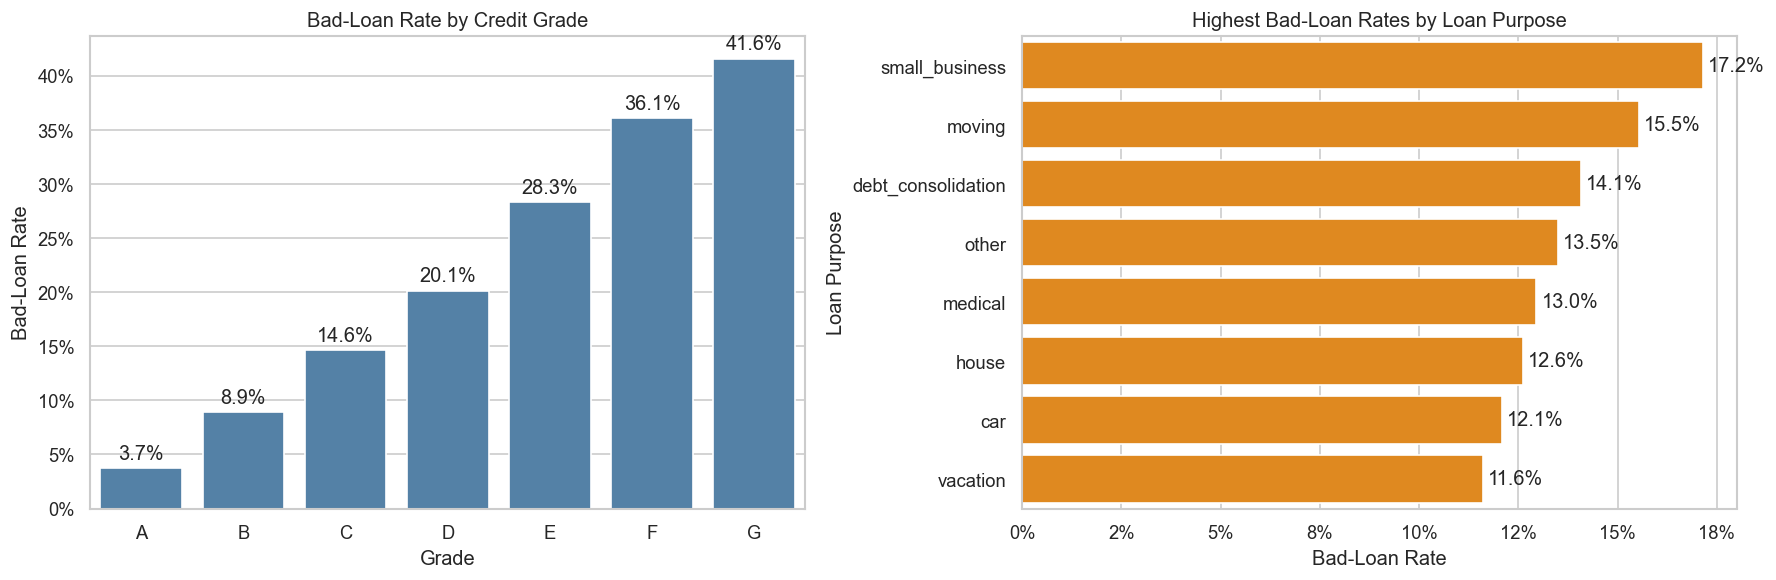

In [16]:
grade_bad_rate = (
    accepted_loans
    .dropna(subset=["grade", "bad_loan"])
    .groupby("grade")
    .agg(bad_loan_rate=("bad_loan", "mean"), loan_count=("bad_loan", "size"))
    .reset_index()
    .sort_values("grade")
)

purpose_bad_rate = (
    accepted_loans
    .dropna(subset=["purpose", "bad_loan"])
    .groupby("purpose")
    .agg(bad_loan_rate=("bad_loan", "mean"), loan_count=("bad_loan", "size"))
    .query("loan_count >= 100")
    .reset_index()
    .sort_values("bad_loan_rate", ascending=False)
)

display(grade_bad_rate)
display(purpose_bad_rate.head(10))

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.barplot(data=grade_bad_rate, x="grade", y="bad_loan_rate", color="steelblue", ax=axes[0])
axes[0].set_title("Bad-Loan Rate by Credit Grade")
axes[0].set_xlabel("Grade")
axes[0].set_ylabel("Bad-Loan Rate")
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
for container in axes[0].containers:
    axes[0].bar_label(
        container,
        labels=[f"{bar.get_height():.1%}" for bar in container],
        padding=3
    )

sns.barplot(data=purpose_bad_rate.head(8), x="bad_loan_rate", y="purpose", color="darkorange", ax=axes[1])
axes[1].set_title("Highest Bad-Loan Rates by Loan Purpose")
axes[1].set_xlabel("Bad-Loan Rate")
axes[1].set_ylabel("Loan Purpose")
axes[1].xaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))

for container in axes[1].containers:
    axes[1].bar_label(
        container,
        labels=[f"{bar.get_width():.1%}" for bar in container],
        padding=3
    )

plt.tight_layout()
plt.show()


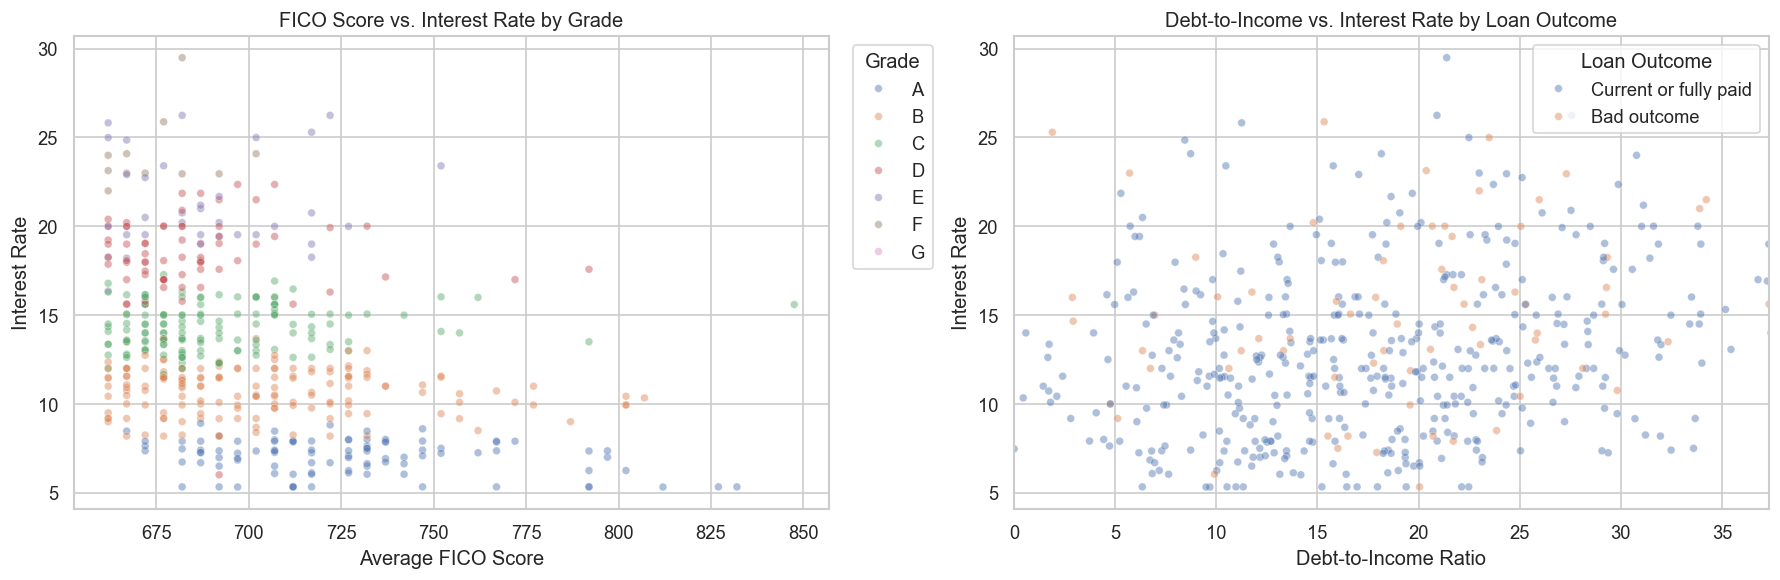

In [17]:
accepted_plot_sample = accepted_loans.dropna(subset=["fico_average", "int_rate", "dti", "bad_loan", "grade"]).sample(
    n=min(500, accepted_loans.dropna(subset=["fico_average", "int_rate", "dti", "bad_loan", "grade"]).shape[0]),
    random_state=0
).copy()
accepted_plot_sample["Loan outcome"] = np.where(accepted_plot_sample["bad_loan"] == 1, "Bad outcome", "Current or fully paid")

grade_order = ["A", "B", "C", "D", "E", "F", "G"]

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

sns.scatterplot(
    data=accepted_plot_sample,
    x="fico_average",
    y="int_rate",
    hue="grade",
    hue_order=grade_order,   # sorts grade order
    alpha=0.45,
    s=22,
    ax=axes[0]
)

axes[0].set_title("FICO Score vs. Interest Rate by Grade")
axes[0].set_xlabel("Average FICO Score")
axes[0].set_ylabel("Interest Rate")
axes[0].legend(title="Grade", bbox_to_anchor=(1.02, 1), loc="upper left")



sns.scatterplot(
    data=accepted_plot_sample,
    x="dti",
    y="int_rate",
    hue="Loan outcome",
    alpha=0.45,
    s=22,
    ax=axes[1]
)
axes[1].set_xlim(0, accepted_plot_sample["dti"].quantile(0.98))
axes[1].set_title("Debt-to-Income vs. Interest Rate by Loan Outcome")
axes[1].set_xlabel("Debt-to-Income Ratio")
axes[1].set_ylabel("Interest Rate")
axes[1].legend(title="Loan Outcome")

plt.tight_layout()
plt.show()


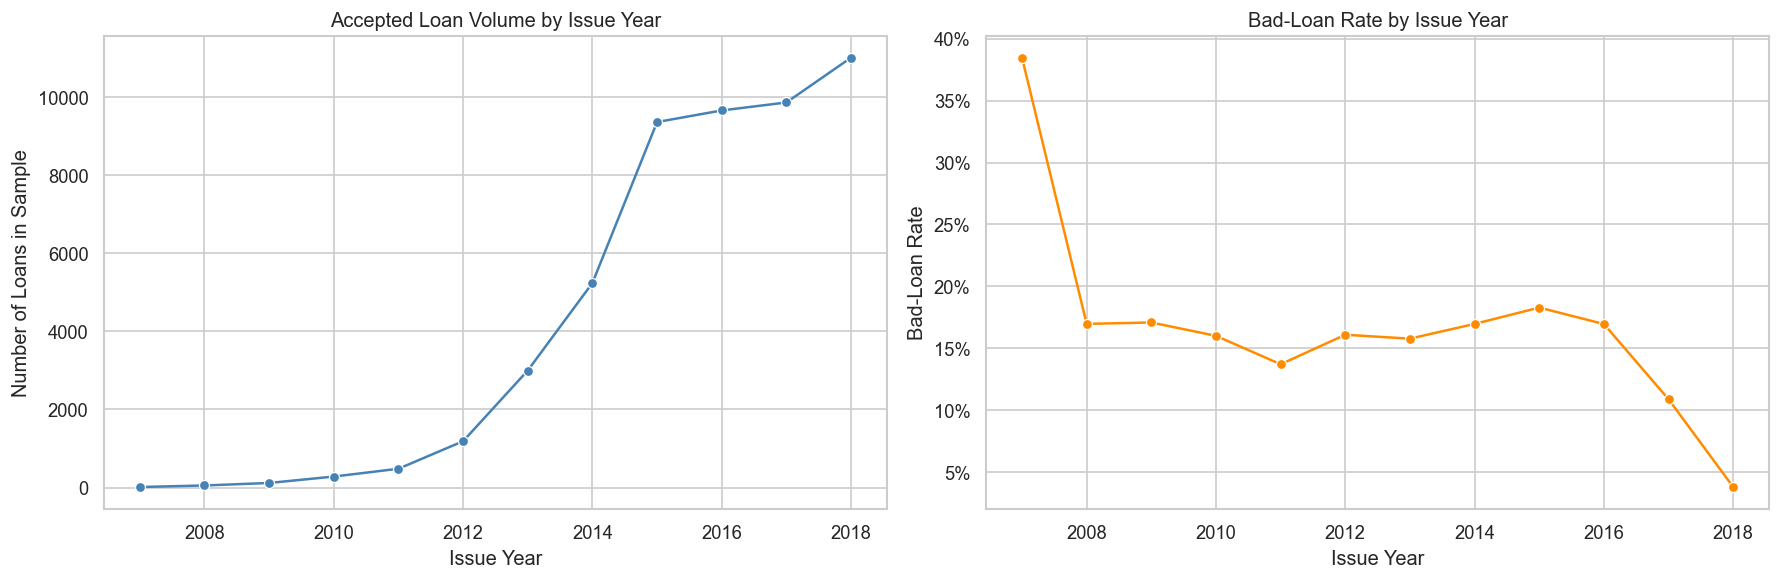

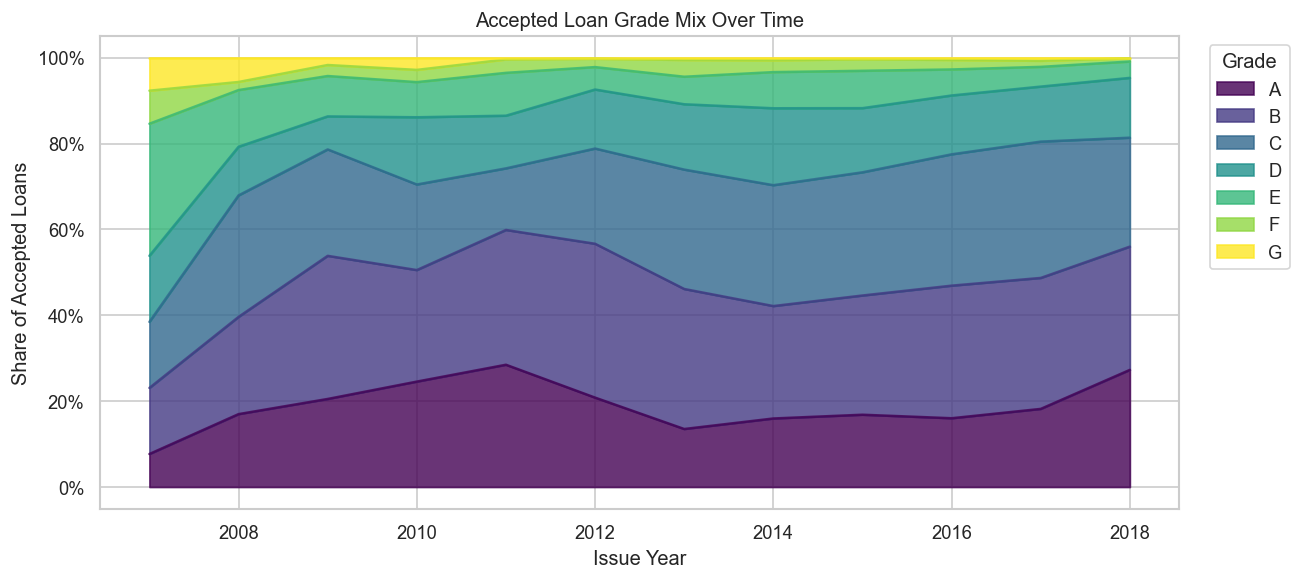

In [18]:
accepted_yearly = (
    accepted_loans
    .dropna(subset=["issue_year"])
    .groupby("issue_year")
    .agg(
        accepted_loans=("loan_amnt", "size"),
        bad_loan_rate=("bad_loan", "mean"),
        average_interest_rate=("int_rate", "mean")
    )
    .reset_index()
)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
sns.lineplot(data=accepted_yearly, x="issue_year", y="accepted_loans", marker="o", ax=axes[0], color="steelblue")
axes[0].set_title("Accepted Loan Volume by Issue Year")
axes[0].set_xlabel("Issue Year")
axes[0].set_ylabel("Number of Loans in Sample")

sns.lineplot(data=accepted_yearly, x="issue_year", y="bad_loan_rate", marker="o", ax=axes[1], color="darkorange")
axes[1].set_title("Bad-Loan Rate by Issue Year")
axes[1].set_xlabel("Issue Year")
axes[1].set_ylabel("Bad-Loan Rate")
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.tight_layout()
plt.show()

accepted_grade_year = (
    accepted_loans
    .dropna(subset=["issue_year", "grade"])
    .groupby(["issue_year", "grade"])
    .size()
    .unstack(fill_value=0)
    .sort_index()
)
accepted_grade_share = accepted_grade_year.div(accepted_grade_year.sum(axis=1), axis=0)

accepted_grade_share.plot.area(figsize=(11, 5), alpha=0.8, colormap="viridis")
plt.title("Accepted Loan Grade Mix Over Time")
plt.xlabel("Issue Year")
plt.ylabel("Share of Accepted Loans")
plt.gca().yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
plt.legend(title="Grade", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()


,column,median,min,max,iqr_outliers,upper_outlier_cutoff
0,loan_amnt,13000.00,500.00,40000.00,784,38000.000
1,annual_inc,65000.00,0.00,8700000.00,2370,162825.000
2,dti,17.94,0.00,999.00,479,43.665
3,revol_bal,11338.00,0.00,689335.00,3064,41637.000
4,revol_util,50.40,0.00,153.00,4,126.450
5,int_rate,12.62,5.31,30.99,923,25.740


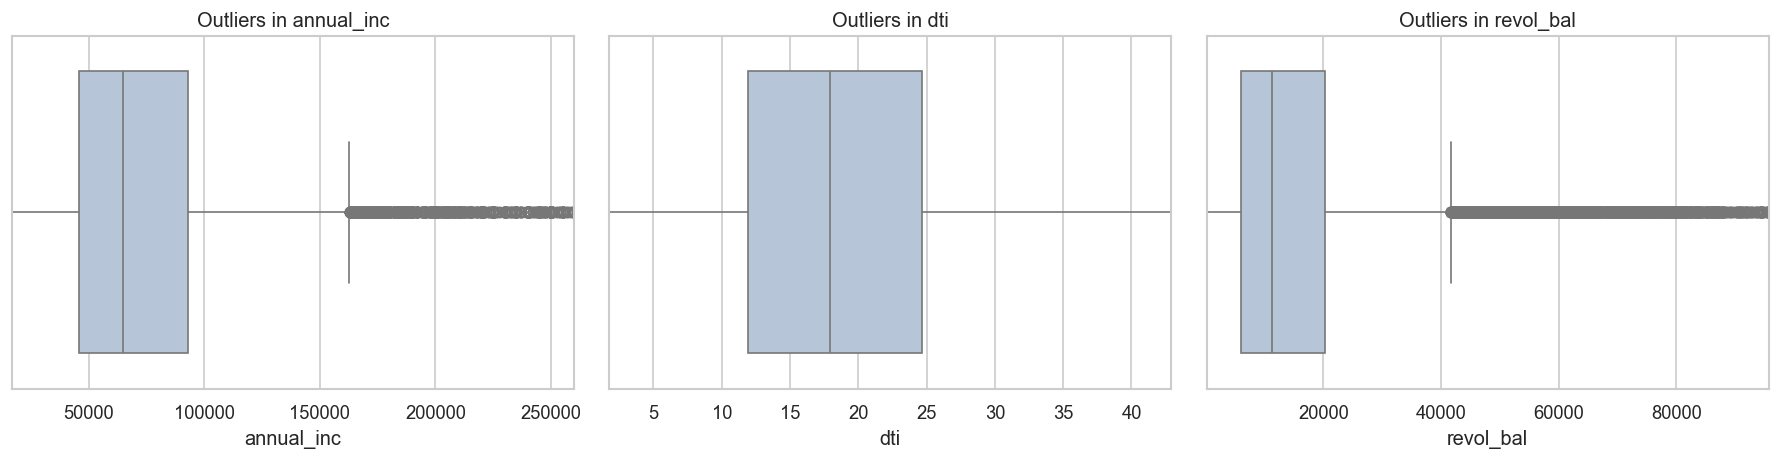

In [19]:
accepted_outlier_columns = ["loan_amnt", "annual_inc", "dti", "revol_bal", "revol_util", "int_rate"]
accepted_outlier_summary = []
for column in accepted_outlier_columns:
    values = accepted_loans[column].dropna()
    q1, q3 = values.quantile([0.25, 0.75])
    iqr = q3 - q1
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr
    accepted_outlier_summary.append({
        "column": column,
        "median": values.median(),
        "min": values.min(),
        "max": values.max(),
        "iqr_outliers": ((values < lower_bound) | (values > upper_bound)).sum(),
        "upper_outlier_cutoff": upper_bound
    })

display(pd.DataFrame(accepted_outlier_summary))

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, ["annual_inc", "dti", "revol_bal"]):
    sns.boxplot(data=accepted_loans, x=column, ax=ax, color="lightsteelblue")
    ax.set_title(f"Outliers in {column}")
    ax.set_xlim(accepted_loans[column].quantile(0.01), accepted_loans[column].quantile(0.99))
plt.tight_layout()
plt.show()


### Accepted Lending Club Loan Dataset Conclusions

The accepted Lending Club data is the strongest dataset for the rubric because it has meaningful numeric variables, categorical risk grades, loan outcomes, and issue dates. I used an evenly spaced sample from the full file so the analysis covers the full 2007-2018 period instead of only the first rows.

The bad-loan correlation chart shows that `int_rate`, FICO score, revolving utilization, debt-to-income, and annual income are the numeric variables most related to bad outcomes. The relationships are not perfect, but they are directionally reasonable: higher interest rates and lower credit scores are associated with more bad outcomes.

The grade and purpose plots are the most useful business visuals. Bad-loan rates rise steadily from grade A to grade G, which means the grade variable is capturing credit risk. Some loan purposes also have worse outcomes than others. The scatterplots add context: FICO score is related to interest rate, and debt-to-income helps show affordability risk.

The time plots are appropriate for this dataset because `issue_d` spans multiple years. Loan volume and grade mix change over time, and the bad-loan rate also varies by issue year. The outlier review shows extreme values in `annual_inc`, `dti`, `revol_bal`, and `revol_util`; those values should be capped, transformed, or investigated before modeling. Highly correlated fields such as `loan_amnt`/`funded_amnt` and `fico_range_low`/`fico_range_high` are likely redundant.


# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

I chose to reproduce a Storytelling With Data style slope chart. The purpose is to make one comparison easy to understand: bad-loan rates increase sharply as credit grade worsens. This fits the second half of Chapter 3 because the chart uses clear visual hierarchy, direct labels, and minimal clutter.


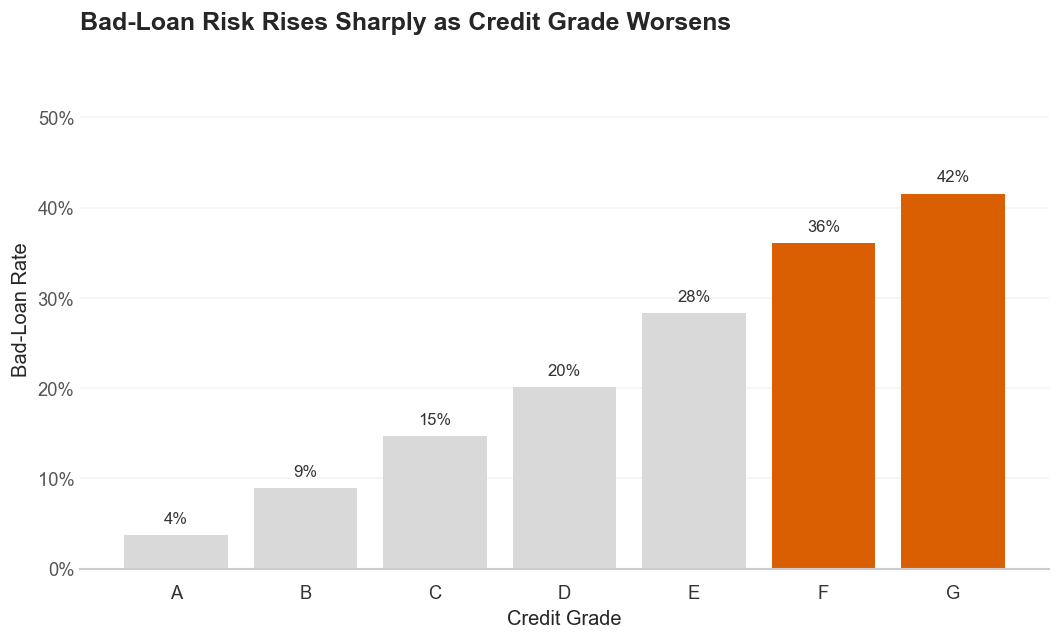

In [166]:
# Storytelling With Data style chart: focus attention on the main pattern.
# Data values are based on the accepted Lending Club sample from Problem 3.
if "accepted_loans" not in globals():
    accepted_path = Path("DATA/All Lending Club Loan Data/accepted_2007_to_2018q4.csv/accepted_2007_to_2018Q4.csv")
    accepted_columns = ["loan_status", "grade"]
    accepted_total_rows = sum(1 for _ in open(accepted_path, encoding="utf-8")) - 1
    accepted_sample_every = max(accepted_total_rows // 50000, 1)
    accepted_loans = pd.read_csv(
        accepted_path,
        usecols=accepted_columns,
        skiprows=lambda row_number: row_number > 0 and row_number % accepted_sample_every != 0,
        low_memory=False
    )
    accepted_loans["bad_loan"] = accepted_loans["loan_status"].isin([
        "Charged Off", "Default", "Late (31-120 days)", "Late (16-30 days)",
        "Does not meet the credit policy. Status:Charged Off"
    ]).astype(int)
grade_story = (
    accepted_loans
    .dropna(subset=["grade", "bad_loan"])
    .groupby("grade")
    .agg(bad_loan_rate=("bad_loan", "mean"), loan_count=("bad_loan", "size"))
    .reset_index()
    .sort_values("grade")
)
fig, ax = plt.subplots(figsize=(9, 5.5))
# Use muted bars for context and one highlight color for the riskiest grades.
colors = ["#d9d9d9" if grade not in ["F", "G"] else "#d95f02" for grade in grade_story["grade"]]
bars = ax.bar(
    grade_story["grade"],
    grade_story["bad_loan_rate"],
    color=colors,
    edgecolor="none"
)
for bar, rate in zip(bars, grade_story["bad_loan_rate"]):
    ax.text(
        bar.get_x() + bar.get_width() / 2,
        rate + 0.01,
        f"{rate:.0%}",
        ha="center",
        va="bottom",
        fontsize=10,
        color="#333333"
    )
rate_a = grade_story.loc[grade_story["grade"] == "A", "bad_loan_rate"].iloc[0]
rate_g = grade_story.loc[grade_story["grade"] == "G", "bad_loan_rate"].iloc[0]

ax.set_title(
    "Bad-Loan Risk Rises Sharply as Credit Grade Worsens",
    loc="left",
    fontsize=15,
    weight="bold",
    pad=12
)

ax.set_xlabel("Credit Grade")
ax.set_ylabel("Bad-Loan Rate")
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda value, _: f"{value:.0%}"))
ax.set_ylim(0, grade_story["bad_loan_rate"].max() + 0.16)
ax.grid(axis="y", alpha=0.2)
ax.xaxis.grid(False)
for spine in ["top", "right", "left"]:
    ax.spines[spine].set_visible(False)
ax.spines["bottom"].set_color("#cccccc")
ax.tick_params(axis="y", length=0, colors="#555555")
ax.tick_params(axis="x", colors="#333333")
plt.tight_layout()
plt.show()


This chart follows the Storytelling With Data approach by leading with the main takeaway in the title, using gray bars for context, and using orange only to emphasize the riskiest grades. The direct percentage labels reduce the need to estimate values from the axis, and the annotation explains why the highlighted grades matter.
